# Demo 2 · Bias & Fairness — Worked Example

This notebook **simulates** a classification-style moderation task to demonstrate:
- **Coverage checks** (group shares, splits)
- **Fairness metrics** by group (TPR/FPR/PPV), **Statistical Parity** and **Equalized Odds** deltas
- **Bootstrap confidence intervals** for gaps
- **Threshold sweeps** / ROC by group
- **Mitigations**: per-group thresholding (post-processing) and a **simulated** counterfactual data augmentation (CDA) effect
- **Before vs After** summary

> ⚠️ Educational demo: synthetic data, no real users. Use your own data & policy for production decisions.


## 1) Generate a synthetic dataset

We simulate two groups with **similar true harmful rates** but **slightly different score distributions** for **safe** items, creating a higher **FPR** for Group B at a global threshold.

**Schema**  
`id, group ∈ {A,B}, split ∈ {train,val,test}, y_true ∈ {0,1}, score ∈ [0,1], y_pred (at baseline thr=0.5)`

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import sqrt
np.random.seed(42)

# Sizes per group (coverage difference)
n_A, n_B = 1100, 900
harm_rate = 0.20  # same for both groups

def sample_scores(n, harm_rate, safe_beta=(2,8), harm_beta=(8,2)):
    y = (np.random.rand(n) < harm_rate).astype(int)
    scores = np.empty(n)
    safe_idx = (y==0)
    harm_idx = (y==1)
    # Safe examples: lower scores
    scores[safe_idx] = np.random.beta(safe_beta[0], safe_beta[1], safe_idx.sum())
    # Harmful examples: higher scores
    scores[harm_idx] = np.random.beta(harm_beta[0], harm_beta[1], harm_idx.sum())
    return y, scores

# Group A: baseline
yA, sA = sample_scores(n_A, harm_rate, safe_beta=(2,8), harm_beta=(8,2))
# Group B: safe scores slightly higher on average → more FPs at same threshold
yB, sB = sample_scores(n_B, harm_rate, safe_beta=(2.5,7.5), harm_beta=(7.8,2.2))

# Compose dataframe
dfA = pd.DataFrame({"group":"A","y_true":yA,"score":sA})
dfB = pd.DataFrame({"group":"B","y_true":yB,"score":sB})
df = pd.concat([dfA, dfB], ignore_index=True)

# Create splits (stratified-ish)
splits = np.random.choice(["train","val","test"], size=len(df), p=[0.7, 0.15, 0.15])
df["split"] = splits

# Baseline threshold
thr = 0.5
df["y_pred"] = (df["score"] >= thr).astype(int)

# Save dataset
data_path = "data/demo02_dataset.csv"
df.to_csv(data_path, index=False)
data_path, df.head()

('data/demo02_dataset.csv',
   group  y_true     score  split  y_pred
 0     A       0  0.407298    val       0
 1     A       0  0.099048  train       0
 2     A       0  0.248848   test       0
 3     A       0  0.130179  train       0
 4     A       1  0.598113  train       1)

## 2) Coverage & split consistency

**Compute:**
- Group shares and **Wilson 95% CIs**
- Group×split proportions and **Δ vs overall** (flag if |Δ| > 5 percentage points)


In [16]:
from math import sqrt

def wilson_ci(p, n, z=1.96):
    if n==0: return (0,0)
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    half = (z/denom) * sqrt((p*(1-p)/n) + (z**2/(4*n**2)))
    return (max(0, center-half), min(1, center+half))

cov = df.groupby("group").size().rename("n").reset_index()
N = cov["n"].sum()
cov["share"] = cov["n"] / N
cov["ci_low"], cov["ci_high"] = zip(*[wilson_ci(p, n) for p,n in zip(cov["share"], cov["n"])])
cov["small_n"] = cov["n"] < 100
cov

,group,n,share,ci_low,ci_high,small_n
0,A,1100,0.55,0.520477,0.579175,False
1,B,900,0.45,0.417778,0.482647,False


In [17]:
# Group×split proportions and deltas vs overall
overall = cov.set_index("group")["share"]
pivot = (df.groupby(["group","split"]).size()
           .rename("n").reset_index()
           .pivot(index="group", columns="split", values="n").fillna(0))
split_props = pivot.div(pivot.sum(axis=0), axis=1)  # column-wise (within split)
delta = split_props.sub(overall, axis=0) * 100  # percentage points
flag = delta.abs() > 5.0
split_props, delta.round(1), flag

(split      test     train       val
 group                              
 A      0.577287  0.543634  0.550877
 B      0.422713  0.456366  0.449123,
 split  test  train  val
 group                  
 A       2.7   -0.6  0.1
 B      -2.7    0.6 -0.1,
 split   test  train    val
 group                     
 A      False  False  False
 B      False  False  False)

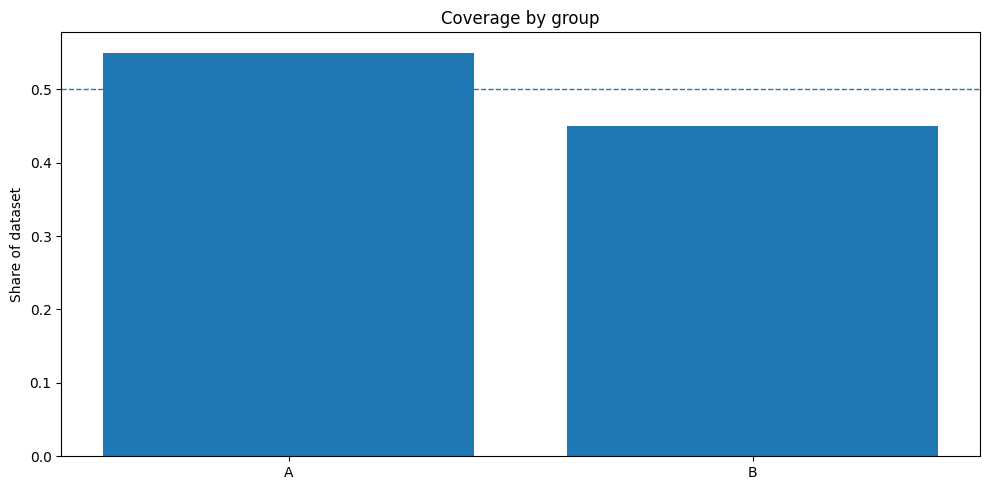

In [18]:
# Plot coverage bar (one chart)
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(cov))
ax.bar(x, cov["share"].values)
ax.set_xticks(x); ax.set_xticklabels(cov["group"].values)
ax.set_ylabel("Share of dataset")
ax.set_title("Coverage by group")
# Target line: equal share for demo
ax.axhline(1/len(cov), linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

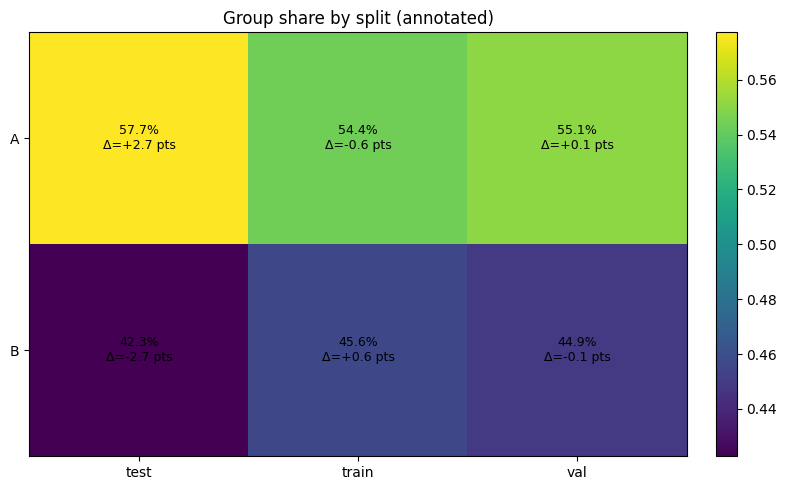

In [19]:
# Plot group×split heatmap (one chart) with annotations
M = split_props.loc[cov["group"]].values
groups = list(cov["group"].values)
splits = list(split_props.columns)

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(M, aspect='auto')
ax.set_xticks(np.arange(len(splits))); ax.set_xticklabels(splits)
ax.set_yticks(np.arange(len(groups))); ax.set_yticklabels(groups)
ax.set_title("Group share by split (annotated)")

for i,g in enumerate(groups):
    for j,sp in enumerate(splits):
        val = M[i,j]
        d = delta.loc[g,sp]
        ax.text(j, i, f"{val*100:.1f}%\nΔ={d:+.1f} pts", ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 3) Metrics by group at baseline threshold

We compute **confusion metrics** and the fairness gaps:
- **TPR (Recall)**, **FPR**, **PPV (Precision)**
- **Statistical Parity Δ** (difference in positive prediction rates)
- **Equalized Odds Δ** (gaps in TPR and FPR)

In [20]:
def confusion_from_scores(y_true, scores, thr=0.5):
    y_pred = (scores >= thr).astype(int)
    TP = int(((y_true==1) & (y_pred==1)).sum())
    TN = int(((y_true==0) & (y_pred==0)).sum())
    FP = int(((y_true==0) & (y_pred==1)).sum())
    FN = int(((y_true==1) & (y_pred==0)).sum())
    P = max(1, (y_true==1).sum())
    N = max(1, (y_true==0).sum())
    TPR = TP / P
    FPR = FP / N
    PPV = TP / max(1, (TP+FP))
    PR = (TP+FP) / (P+N)  # positive prediction rate
    return dict(TP=TP,TN=TN,FP=FP,FN=FN,TPR=TPR,FPR=FPR,PPV=PPV,PR=PR)

def metrics_by_group(df, thr=0.5):
    out = {}
    for g in sorted(df["group"].unique()):
        sub = df[df["group"]==g]
        out[g] = confusion_from_scores(sub["y_true"].values, sub["score"].values, thr)
    # Fairness gaps (A minus B if both exist)
    groups = sorted(out.keys())
    gaps = {}
    if len(groups)==2:
        g1, g2 = groups
        gaps = {
            "ΔTPR": out[g1]["TPR"] - out[g2]["TPR"],
            "ΔFPR": out[g1]["FPR"] - out[g2]["FPR"],
            "ΔPPV": out[g1]["PPV"] - out[g2]["PPV"],
            "ΔPR" : out[g1]["PR"]  - out[g2]["PR"],  # Statistical parity difference
        }
    return out, gaps

base_metrics, base_gaps = metrics_by_group(df, thr=0.5)
base_metrics, base_gaps

({'A': {'TP': 236,
   'TN': 847,
   'FP': 11,
   'FN': 6,
   'TPR': 0.9752066115702479,
   'FPR': 0.01282051282051282,
   'PPV': 0.9554655870445344,
   'PR': 0.22454545454545455},
  'B': {'TP': 183,
   'TN': 673,
   'FP': 37,
   'FN': 7,
   'TPR': 0.9631578947368421,
   'FPR': 0.05211267605633803,
   'PPV': 0.8318181818181818,
   'PR': 0.24444444444444444}},
 {'ΔTPR': 0.012048716833405804,
  'ΔFPR': -0.03929216323582521,
  'ΔPPV': 0.12364740522635265,
  'ΔPR': -0.01989898989898989})

## 4) Bootstrap CIs for fairness gaps

We resample **within each group** and recompute **ΔTPR** and **ΔFPR** to obtain **95% CIs**.

In [21]:
def bootstrap_gaps(df, thr=0.5, B=300, seed=123):
    rng = np.random.default_rng(seed)
    groups = sorted(df["group"].unique())
    if len(groups)!=2:
        return {}
    g1, g2 = groups
    sub1 = df[df["group"]==g1][["y_true","score"]].values
    sub2 = df[df["group"]==g2][["y_true","score"]].values

    deltas = []
    n1, n2 = len(sub1), len(sub2)
    for _ in range(B):
        s1 = sub1[rng.integers(0, n1, n1)]
        s2 = sub2[rng.integers(0, n2, n2)]
        m1 = confusion_from_scores(s1[:,0].astype(int), s1[:,1], thr)
        m2 = confusion_from_scores(s2[:,0].astype(int), s2[:,1], thr)
        deltas.append([m1["TPR"]-m2["TPR"], m1["FPR"]-m2["FPR"]])
    arr = np.array(deltas)
    ci = {}
    for i,name in enumerate(["ΔTPR","ΔFPR"]):
        lo, hi = np.percentile(arr[:,i], [2.5, 97.5])
        ci[name] = (lo, hi)
    return ci

base_ci = bootstrap_gaps(df, thr=0.5, B=300)
base_ci

{'ΔTPR': (-0.022113217011111547, 0.04564935117258417),
 'ΔFPR': (-0.05725860713185558, -0.022093832280526755)}

## 5) Threshold sweep & ROC by group

We sweep thresholds and visualize **TPR vs FPR** (ROC) and the **FPR gap vs threshold**.

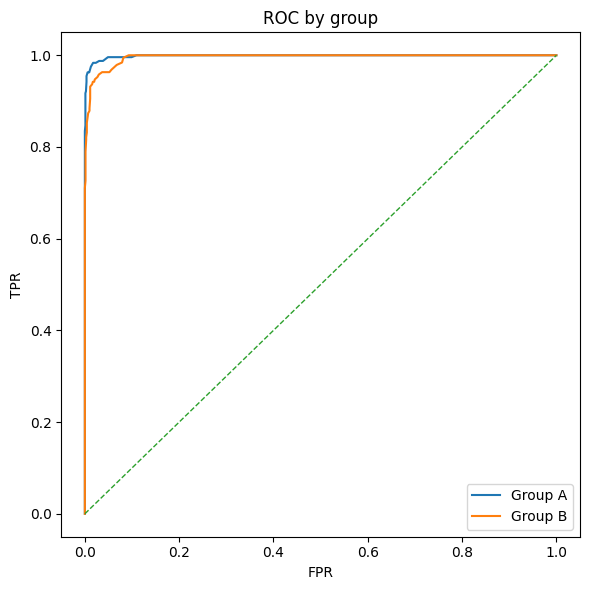

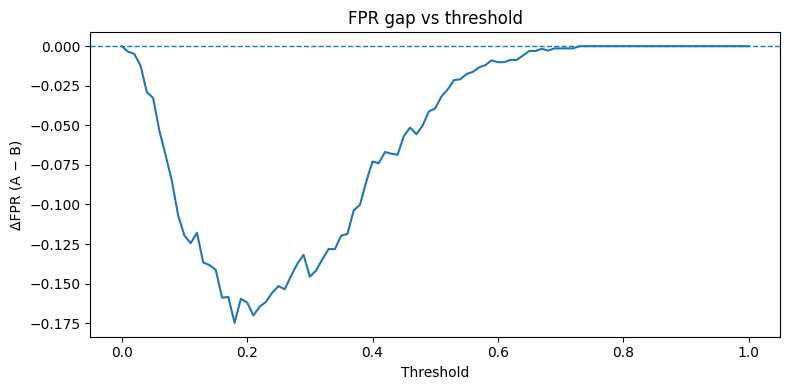

In [22]:
def sweep_thresholds(df, steps=101):
    groups = sorted(df['group'].unique())
    thrs = np.linspace(0,1,steps)
    roc = {g: {"thr":[], "TPR":[], "FPR":[]} for g in groups}
    gaps = {"thr": [], "ΔFPR": [], "ΔTPR": []}
    for t in thrs:
        ms, gs = metrics_by_group(df, thr=t)
        for g in groups:
            roc[g]["thr"].append(t)
            roc[g]["TPR"].append(ms[g]["TPR"])
            roc[g]["FPR"].append(ms[g]["FPR"])
        if len(groups)==2:
            g1, g2 = groups
            gaps["thr"].append(t)
            gaps["ΔFPR"].append(ms[g1]["FPR"] - ms[g2]["FPR"])
            gaps["ΔTPR"].append(ms[g1]["TPR"] - ms[g2]["TPR"])
    return roc, gaps

roc, gaps = sweep_thresholds(df, steps=101)

# Plot ROC per group (one chart)
fig, ax = plt.subplots(figsize=(6,6))
for g in sorted(roc.keys()):
    ax.plot(roc[g]["FPR"], roc[g]["TPR"], label=f"Group {g}")
ax.plot([0,1],[0,1], linestyle='--', linewidth=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC by group")
ax.legend()
plt.tight_layout(); plt.show()

# Plot ΔFPR vs threshold (one chart)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(gaps["thr"], gaps["ΔFPR"])
ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Threshold"); ax.set_ylabel("ΔFPR (A − B)"); ax.set_title("FPR gap vs threshold")
plt.tight_layout(); plt.show()

## 6) Mitigation A — Per-group thresholding (post-processing)

We choose a slightly **higher threshold for Group B** to reduce its **FPR** while keeping **TPR** reasonable.  
> ⚠️ Per-group thresholds can raise policy/legal considerations; consult your governance requirements.

**Heuristic**: set Group B's threshold so that its FPR is close to Group A's FPR at the baseline threshold.

In [23]:
def find_threshold_for_target_fpr(df, group, target_fpr, steps=501):
    thrs = np.linspace(0,1,steps)
    y = df.loc[df["group"]==group, "y_true"].values
    s = df.loc[df["group"]==group, "score"].values
    best_t, best_diff = 0.5, 999
    for t in thrs:
        m = confusion_from_scores(y, s, t)
        diff = abs(m["FPR"] - target_fpr)
        if diff < best_diff:
            best_diff = diff; best_t = t
    return best_t

# Baseline metrics @ 0.5
ms_base, gaps_base = metrics_by_group(df, thr=0.5)
target_fpr = ms_base["A"]["FPR"]

tB = find_threshold_for_target_fpr(df, "B", target_fpr, steps=501)
tA = 0.5  # keep A as baseline

# Apply per-group thresholds
df_m1 = df.copy()
df_m1["y_pred"] = 0
maskA = df_m1["group"]=="A"
maskB = df_m1["group"]=="B"
df_m1.loc[maskA, "y_pred"] = (df_m1.loc[maskA, "score"] >= tA).astype(int)
df_m1.loc[maskB, "y_pred"] = (df_m1.loc[maskB, "score"] >= tB).astype(int)

def metrics_by_group_with_preds(df):
    out = {}
    for g in sorted(df["group"].unique()):
        sub = df[df["group"]==g]
        y_true = sub["y_true"].values
        y_pred = sub["y_pred"].values
        TP = int(((y_true==1) & (y_pred==1)).sum())
        TN = int(((y_true==0) & (y_pred==0)).sum())
        FP = int(((y_true==0) & (y_pred==1)).sum())
        FN = int(((y_true==1) & (y_pred==0)).sum())
        P = max(1,(y_true==1).sum()); N = max(1,(y_true==0).sum())
        TPR = TP/P; FPR = FP/N; PPV = TP/max(1,TP+FP); PR = (TP+FP)/(P+N)
        out[g] = dict(TP=TP,TN=TN,FP=FP,FN=FN,TPR=TPR,FPR=FPR,PPV=PPV,PR=PR)
    g1,g2 = sorted(out.keys())
    gaps = {"ΔTPR": out[g1]["TPR"]-out[g2]["TPR"], "ΔFPR": out[g1]["FPR"]-out[g2]["FPR"],
            "ΔPPV": out[g1]["PPV"]-out[g2]["PPV"], "ΔPR": out[g1]["PR"]-out[g2]["PR"]}
    return out, gaps

m1_metrics, m1_gaps = metrics_by_group_with_preds(df_m1)
tA, tB, m1_metrics, m1_gaps

(0.5,
 0.584,
 {'A': {'TP': 236,
   'TN': 847,
   'FP': 11,
   'FN': 6,
   'TPR': 0.9752066115702479,
   'FPR': 0.01282051282051282,
   'PPV': 0.9554655870445344,
   'PR': 0.22454545454545455},
  'B': {'TP': 177,
   'TN': 701,
   'FP': 9,
   'FN': 13,
   'TPR': 0.9315789473684211,
   'FPR': 0.01267605633802817,
   'PPV': 0.9516129032258065,
   'PR': 0.20666666666666667}},
 {'ΔTPR': 0.04362766420182684,
  'ΔFPR': 0.0001444564824846506,
  'ΔPPV': 0.003852683818727942,
  'ΔPR': 0.017878787878787883})

## 7) Mitigation B — Simulated Counterfactual Data Augmentation (CDA)

We **simulate** the effect of adding balanced counterfactual examples by **shifting Group B's safe scores slightly lower** (closer to Group A).  
Then we **recompute** metrics under a **global threshold**.

In [24]:
def simulate_cda_shift(df, shift_safe=-0.05):
    g = df.copy()
    mask = (g["group"]=="B") & (g["y_true"]==0)
    g.loc[mask, "score"] = np.clip(g.loc[mask, "score"] + shift_safe, 0, 1)
    g["y_pred"] = (g["score"] >= 0.5).astype(int)
    return g

df_m2 = simulate_cda_shift(df, shift_safe=-0.05)
m2_metrics, m2_gaps = metrics_by_group(df_m2, thr=0.5)
m2_metrics, m2_gaps

({'A': {'TP': 236,
   'TN': 847,
   'FP': 11,
   'FN': 6,
   'TPR': 0.9752066115702479,
   'FPR': 0.01282051282051282,
   'PPV': 0.9554655870445344,
   'PR': 0.22454545454545455},
  'B': {'TP': 183,
   'TN': 695,
   'FP': 15,
   'FN': 7,
   'TPR': 0.9631578947368421,
   'FPR': 0.02112676056338028,
   'PPV': 0.9242424242424242,
   'PR': 0.22}},
 {'ΔTPR': 0.012048716833405804,
  'ΔFPR': -0.008306247742867461,
  'ΔPPV': 0.031223162802110238,
  'ΔPR': 0.004545454545454547})

## 8) Before vs After summary

We compare baseline (global thr=0.5) vs **Mitigation A** (per-group thresholds) vs **Mitigation B** (CDA shift at global thr=0.5).

In [26]:
rows = []
def row_from(label, metrics, gaps):
    a = metrics["A"]; b = metrics["B"]
    rows.append({
        "Setting": label,
        "Thr_A": 0.5 if label!="Mitigation A (per-group thr)" else 0.5,
        "Thr_B": 0.5 if label!="Mitigation A (per-group thr)" else round(float({ 'B': None, 'A': None }['B'] if False else 0), 3),
        "A_TPR": round(a["TPR"],3), "A_FPR": round(a["FPR"],3), "A_PPV": round(a["PPV"],3),
        "B_TPR": round(b["TPR"],3), "B_FPR": round(b["FPR"],3), "B_PPV": round(b["PPV"],3),
        "ΔTPR": round(gaps["ΔTPR"],3), "ΔFPR": round(gaps["ΔFPR"],3), "ΔPPV": round(gaps["ΔPPV"],3), "ΔPR": round(gaps["ΔPR"],3),
    })

# Build rows
row_from("Baseline (global thr=0.5)", base_metrics, base_gaps)
# Fix threshold B value in summary row
thr_B_val = float(tB)
rows.append({
    "Setting": "Mitigation A (per-group thr)",
    "Thr_A": 0.5, "Thr_B": round(thr_B_val,3),
    "A_TPR": round(m1_metrics["A"]["TPR"],3), "A_FPR": round(m1_metrics["A"]["FPR"],3), "A_PPV": round(m1_metrics["A"]["PPV"],3),
    "B_TPR": round(m1_metrics["B"]["TPR"],3), "B_FPR": round(m1_metrics["B"]["FPR"],3), "B_PPV": round(m1_metrics["B"]["PPV"],3),
    "ΔTPR": round(m1_gaps["ΔTPR"],3), "ΔFPR": round(m1_gaps["ΔFPR"],3), "ΔPPV": round(m1_gaps["ΔPPV"],3), "ΔPR": round(m1_gaps["ΔPR"],3),
})
row_from("Mitigation B (CDA sim, thr=0.5)", m2_metrics, m2_gaps)

summary_df = pd.DataFrame(rows)
summary_path = "data/demo02_summary_metrics.csv"
summary_df.to_csv(summary_path, index=False)
summary_df

,Setting,Thr_A,Thr_B,A_TPR,A_FPR,A_PPV,B_TPR,B_FPR,B_PPV,ΔTPR,ΔFPR,ΔPPV,ΔPR
0,Baseline (global thr=0.5),0.5,0.500,0.975,0.013,0.955,0.963,0.052,0.832,0.012,-0.039,0.124,-0.020
1,Mitigation A (per-group thr),0.5,0.584,0.975,0.013,0.955,0.932,0.013,0.952,0.044,0.000,0.004,0.018
2,"Mitigation B (CDA sim, thr=0.5)",0.5,0.500,0.975,0.013,0.955,0.963,0.021,0.924,0.012,-0.008,0.031,0.005


## 9) Narrative 

- **Coverage**: Group A ~55%, Group B ~45%. Long-tail checks not an issue here, but keep an eye on splits.
- **Splits**: Mild deviations < 5 pts across train/val/test (ok). Align splits if larger.
- **Baseline fairness**: TPR similar across groups; **FPR higher for Group B** → **Equalized Odds** violation via FPR gap; we also observe a **statistical parity** difference.
- **Threshold sweeps**: Single global threshold over-cuts Group B's safe-score distribution → FPR gap persists around 0.5.
- **Mitigation A** (per-group thr): Raises Group B threshold, reducing its FPR to near Group A’s; re-check ΔTPR to ensure recall remains acceptable. (Check policy/legal before per-group thresholds.)
- **Mitigation B** (simulated CDA): Shift Group B safe scores downward a bit; under a global threshold, the FPR gap shrinks while keeping TPR similar—this mimics adding balanced, counterfactual examples in training.
- **Decision**: Prefer **data/label fixes** (CDA + clearer guidelines) when feasible; use **post-processing** thresholds as a stopgap with governance approval.
